In [1]:
# 2D histogrammer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
highintppbounds = np.loadtxt('/home/kale-chen/Documents/PET/TimeCalibration/LineSourceStudy/highintppbounds.txt')
lowintppbounds = np.loadtxt('/home/kale-chen/Documents/PET/TimeCalibration/LineSourceStudy/lowintppbounds.txt')
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)

highinteventcounts = np.loadtxt('/home/kale-chen/Documents/PET/TimeCalibration/LineSourceStudy/eventcountsperchannelHighInt.txt')
lowinteventcounts = np.loadtxt('/home/kale-chen/Documents/PET/TimeCalibration/LineSourceStudy/eventcountsperchannelLowInt.txt')

highintoffsets = np.loadtxt('/home/kale-chen/Documents/PET/TimeCalibration/LineSourceStudy/tsvsHighInt/time_offset_calibrationit10.tsv', delimiter = '\t')[:, 4]
lowintoffsets = np.loadtxt('/home/kale-chen/Documents/PET/TimeCalibration/LineSourceStudy/tsvsLowInt/time_offset_calibrationit10.tsv', delimiter = '\t')[:, 4]




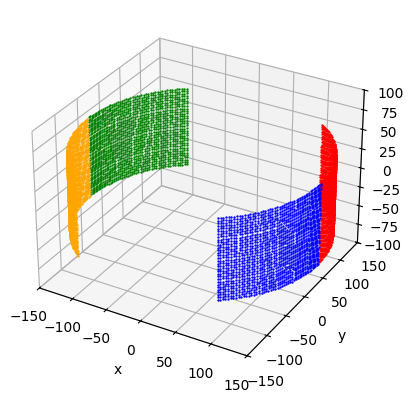

In [132]:
map1 = mapdf.to_numpy()
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for n in range(0, 1024):
    ax.scatter(map1[:,0][n], map1[:,1][n], map1[:,2][n], c='blue', marker='o', s=0.5)
for n in range(1024, 1280):
    ax.scatter(map1[:,0][n], map1[:,1][n], map1[:,2][n], c='blue', marker='o', s=0.5)
for n in range(1792, 2048):
    ax.scatter(map1[:,0][n], map1[:,1][n], map1[:,2][n], c='blue', marker='o', s=0.5)
for n in range(2048, 3072):
    ax.scatter(map1[:,0][n], map1[:,1][n], map1[:,2][n], c='red', marker='o', s=0.5)
for n in range(1280, 1536):
    ax.scatter(map1[:,0][n], map1[:,1][n], map1[:,2][n], c='red', marker='o', s=0.5)
for n in range(1536, 1792):
    ax.scatter(map1[:,0][n], map1[:,1][n], map1[:,2][n], c='red', marker='o', s=0.5)
for n in range(3072, 4096):
    ax.scatter(map1[:,0][n], map1[:,1][n], map1[:,2][n], c='green', marker='o', s=0.5)
for n in range(4352, 4608):
    ax.scatter(map1[:,0][n], map1[:,1][n], map1[:,2][n], c='green', marker='o', s=0.5)
for n in range(4608, 4864):
    ax.scatter(map1[:,0][n], map1[:,1][n], map1[:,2][n], c='green', marker='o', s=0.5)
for n in range(5120, 6144):
    ax.scatter(map1[:,0][n], map1[:,1][n], map1[:,2][n], c='orange', marker='o', s=0.5)
for n in range(4096, 4352):
    ax.scatter(map1[:,0][n], map1[:,1][n], map1[:,2][n], c='orange', marker='o', s=0.5)
for n in range(4864, 5120):
    ax.scatter(map1[:,0][n], map1[:,1][n], map1[:,2][n], c='orange', marker='o', s=0.5)

ax.set_xlim(-150, 150)
ax.set_ylim(-150, 150)
ax.set_zlim(-100, 100)
ax.set_xlabel('x')
ax.set_ylabel('y')

plt.show()

In [3]:
# 2D crystal layout from mapdf
mapL = mapdf.iloc[3072:]
mapR = mapdf.iloc[:3072]

mapL = np.round(mapL, 2)
mapR = np.round(mapR, 2)



ycoordsL, countsL = np.unique(mapL.iloc[:, 1], return_counts=True)
zcoordsL, countsL = np.unique(mapL.iloc[:, 2], return_counts=True)

ycoordsR, countsR = np.unique(mapR.iloc[:, 1], return_counts=True)
ycoordsR = ycoordsR[::-1] # To keep view from isocenter outwards
zcoordsR, countsR = np.unique(mapR.iloc[:, 2], return_counts=True)

scanner_arc_L = np.zeros((32, 96))
scanner_arc_R = np.zeros((32, 96))

for i in range(3072):
    scanner_arc_R[np.where(zcoordsR == mapR.iloc[i, 2]), np.where(ycoordsR == mapR.iloc[i, 1])] = i

for i in range(3072):
    scanner_arc_L[np.where(zcoordsL == mapL.iloc[i, 2]), np.where(ycoordsL == mapL.iloc[i, 1])] = i+3072

In [28]:
# Mapping data onto crystal layout
heatmapR = np.zeros((32, 96))
for i in range(3072):
    index = np.where(scanner_arc_R == i)
    meanhigh = (highintppbounds[i][0] + highintppbounds[i][1]) / 2
    meanlow = (lowintppbounds[i][0] + lowintppbounds[i][1]) / 2
    if meanhigh > 1 and meanlow > 1:
        heatmapR[index] = meanhigh / meanlow
    else:
        heatmapR[index] = -1
heatmapL = np.zeros((32, 96))
for i in range(3072, 6144):
    index = np.where(scanner_arc_L == i)
    meanhigh = (highintppbounds[i][0] + highintppbounds[i][1]) / 2
    meanlow = (lowintppbounds[i][0] + lowintppbounds[i][1]) / 2
    if meanhigh > 1 and meanlow > 1:
        heatmapL[index] = meanhigh / meanlow
    else:
        heatmapL[index] = -1



In [5]:
# Mapping event counts onto crystal layout
scale_ratio = 353051.5233333333 / 4189.482692307693

heatmapR = np.zeros((32, 96))
heatmapL = np.zeros((32, 96))

for i in range(3072):
    index = np.where(scanner_arc_R == i)
    if highinteventcounts[i] > 0 and lowinteventcounts[i] > 0:
        heatmapR[index] = highinteventcounts[i] / lowinteventcounts[i] / scale_ratio
    else:
        heatmapR[index] = -1
for i in range(3072, 6144):
    index = np.where(scanner_arc_L == i)
    if highinteventcounts[i] > 0 and lowinteventcounts[i] > 0:
        heatmapL[index] = highinteventcounts[i] / lowinteventcounts[i] / scale_ratio
    else:
        heatmapL[index] = -1


In [50]:
# Mapping offset ratios onto crystal layout
heatmapR = np.zeros((32, 96))
heatmapL = np.zeros((32, 96))

for i in range(3072):
    index = np.where(scanner_arc_R == i)
    try:
        heatmapR[index] = np.abs(highintoffsets[i] / lowintoffsets[i])
    except:
        heatmapR[index] = -1
for i in range(3072, 6144):
    index = np.where(scanner_arc_L == i)
    try:
        heatmapL[index] = np.abs(highintoffsets[i] / lowintoffsets[i])
    except:
        heatmapL[index] = -1


/tmp/ipykernel_1071305/1486143129.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  heatmapR[index] = np.abs(highintoffsets[i] / lowintoffsets[i])


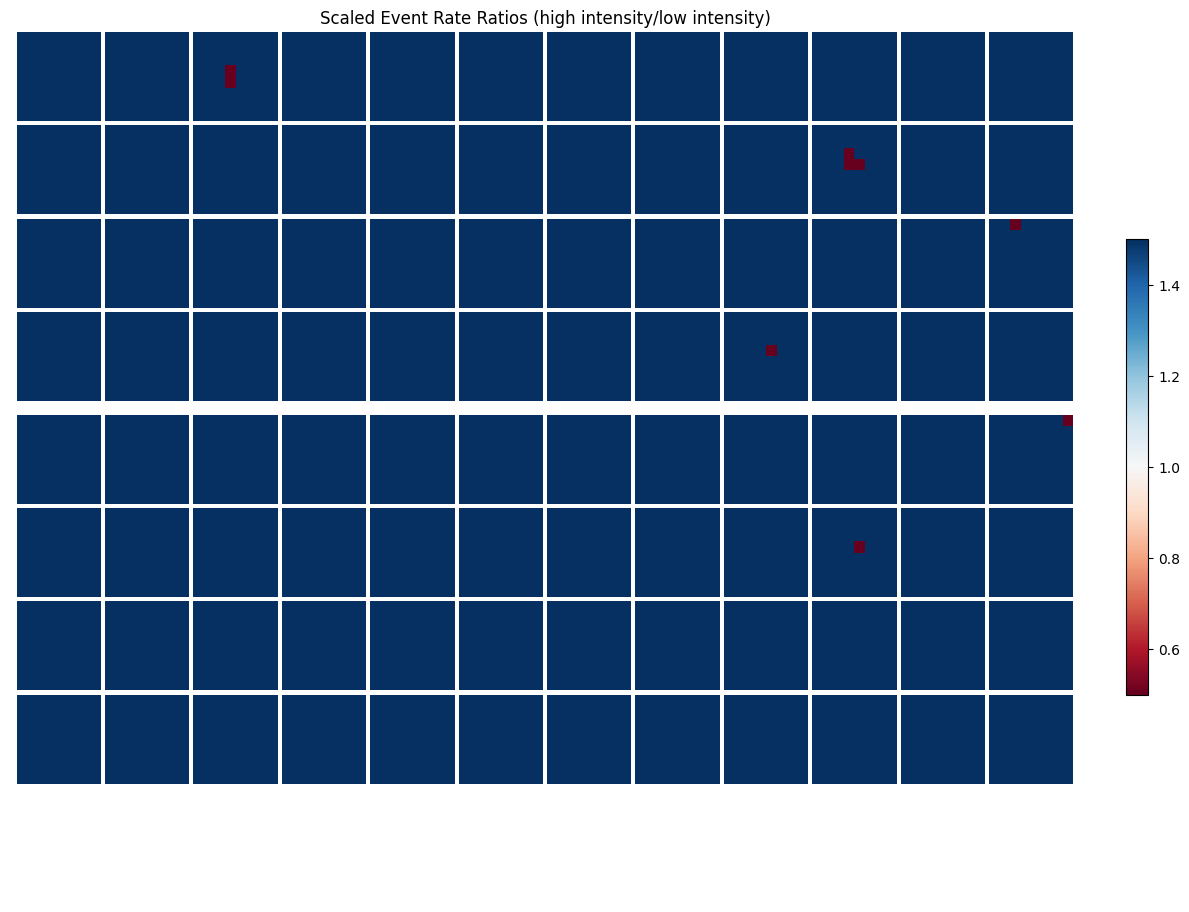

In [ ]:
# Custom ratio heatmap

face_dim = 3.2
space = 1.2
blank_color = 'black'
cmap = plt.get_cmap('RdBu') # 'seismic' or 'RdBu' or 'rwb'
ratio_range = 0.5
minmaxratios = [1 - ratio_range, 1 + ratio_range]
def getcolor(value):
    if value < minmaxratios[0]:
        return cmap(0)
    elif value > minmaxratios[1]:
        return cmap(1.0)
    else:
        return cmap((value - minmaxratios[0]) / (minmaxratios[1] - minmaxratios[0]))
    
fig, ax = plt.subplots(figsize = (12, 9))

#rect = patches.Rectangle((-2, -104.8), 324.4, 225.6, facecolor='black', alpha = 0.2)
#ax.add_patch(rect)

# Plot R
for z in range(32):
    zspace = z // 8 * space
    for y in range(96):
        yspace = y // 8 * space
        if heatmapR[z, y] != -1:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=getcolor(heatmapR[z, y]))
            ax = plt.gca()
            ax.add_patch(rect)
        else:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=blank_color)
            ax = plt.gca()
            ax.add_patch(rect)

# Plot L
for z in range(32):
    zspace = z // 8 * space 
    for y in range(96):
        yspace = y // 8 * space
        if heatmapL[z, y] != -1:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)+ 110), face_dim, face_dim, facecolor=getcolor(heatmapL[z, y]))
            ax = plt.gca()
            ax.add_patch(rect)
        else:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace) + 110), face_dim, face_dim, facecolor=blank_color)
            ax = plt.gca()
            ax.add_patch(rect)

mappable = plt.cm.ScalarMappable(cmap=cmap)
mappable.set_array(minmaxratios)
plt.colorbar(mappable, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)


plt.xlim(-2,322.4)
pady = 32
plt.ylim(-104.8 - pady, 113.2)
plt.axis('off')
plt.tight_layout()
plt.title('Scaled Event Rate Ratios (high intensity/low intensity)')
plt.show()

In [6]:
heatmapRlow = np.zeros((32, 96))
heatmapLlow = np.zeros((32, 96))
heatmapRhigh = np.zeros((32, 96))
heatmapLhigh = np.zeros((32, 96))

for i in range(3072):
    index = np.where(scanner_arc_R == i)
    #heatmapRlow[index] = (lowintppbounds[i][0] + lowintppbounds[i][1]) / 2
    #heatmapRhigh[index] = (highintppbounds[i][0] + highintppbounds[i][1]) / 2
    heatmapRhigh[index] = lowinteventcounts[i] * scale_ratio
    #heatmapRhigh[index] = highintoffsets[i]
    #heatmapRlow[index] = lowintoffsets[i]
for i in range(3072, 6144):
    index = np.where(scanner_arc_L == i)
    #heatmapLlow[index] = (lowintppbounds[i][0] + lowintppbounds[i][1]) / 2
    #heatmapLhigh[index] = (highintppbounds[i][0] + highintppbounds[i][1]) / 2
    heatmapLhigh[index] = lowinteventcounts[i] * scale_ratio
    #heatmapLhigh[index] = highintoffsets[i]
    #heatmapLlow[index] = lowintoffsets[i]
#heatmapmin = np.sort(np.concatenate([heatmapRlow.flatten(), heatmapLlow.flatten(), heatmapRhigh.flatten(), heatmapLhigh.flatten()]))
heatmapmin = np.sort(np.concatenate([heatmapRhigh.flatten(), heatmapLhigh.flatten()]))
heatmapmin = heatmapmin[len(heatmapmin) // 20]
#heatmapmax = np.sort(np.concatenate([heatmapRlow.flatten(), heatmapLlow.flatten(), heatmapRhigh.flatten(), heatmapLhigh.flatten()]))
heatmapmax = np.sort(np.concatenate([heatmapRhigh.flatten(), heatmapLhigh.flatten()]))
heatmapmax = heatmapmax[len(heatmapmax) * 19 // 20]


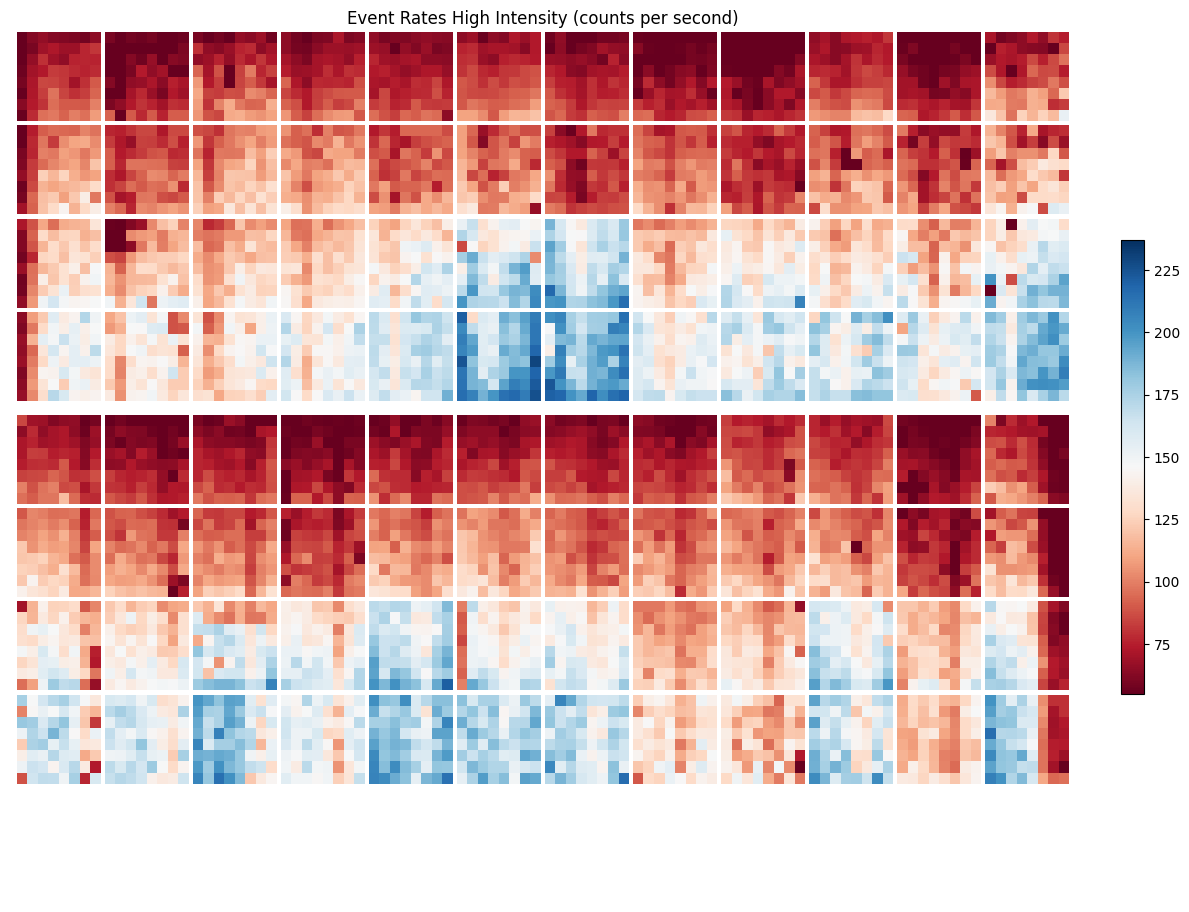

In [8]:
# Custom base values heatmap

heatmapR = np.zeros((32, 96))
heatmapL = np.zeros((32, 96))

for i in range(3072):
    index = np.where(scanner_arc_R == i)
    heatmapR[index] = highinteventcounts[i]
    #heatmapR[index] = lowinteventcounts[i] * scale_ratio
    #heatmapR[index] = (highintppbounds[i][0] + highintppbounds[i][1]) / 2
    #heatmapR[index] = (lowintppbounds[i][0] + lowintppbounds[i][1]) / 2
    #heatmapR[index] = heatmapRhigh[index]
    #heatmapR[index] = heatmapRlow[index]
for i in range(3072, 6144):
    index = np.where(scanner_arc_L == i)
    heatmapL[index] = highinteventcounts[i]
    #heatmapL[index] = lowinteventcounts[i] * scale_ratio
    #heatmapL[index] = (highintppbounds[i][0] + highintppbounds[i][1]) / 2
    #heatmapL[index] = (lowintppbounds[i][0] + lowintppbounds[i][1]) / 2
    #heatmapL[index] = heatmapLhigh[index]
    #heatmapL[index] = heatmapLlow[index]
# Dead cells
#for i in range(32):
#    for j in range(96):
#        if heatmapR[i, j] < 1:
#            heatmapR[i, j] = -1
#       if heatmapL[i, j] < 1:
#           heatmapL[i, j] = -1

face_dim = 3.2
space = 1.2
blank_color = 'black'
cmap = plt.get_cmap('RdBu') # 'seismic' or 'RdBu' or 'rwb'
def getcolor(value):
    if value < heatmapmin:
        return cmap(0)
    elif value > heatmapmax:
        return cmap(1.0)
    else:
        return cmap((value - heatmapmin) / (heatmapmax - heatmapmin))
    
fig, ax = plt.subplots(figsize = (12, 9))

#rect = patches.Rectangle((-2, -104.8), 324.4, 225.6, facecolor='black', alpha = 0.2)
#ax.add_patch(rect)

# Plot R
for z in range(32):
    zspace = z // 8 * space
    for y in range(96):
        yspace = y // 8 * space
        if heatmapR[z, y] != -1:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=getcolor(heatmapR[z, y]))
            ax = plt.gca()
            ax.add_patch(rect)
        else:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)), face_dim, face_dim, facecolor=blank_color)
            ax = plt.gca()
            ax.add_patch(rect)

# Plot L
for z in range(32):
    zspace = z // 8 * space 
    for y in range(96):
        yspace = y // 8 * space
        if heatmapL[z, y] != -1:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)+ 110), face_dim, face_dim, facecolor=getcolor(heatmapL[z, y]))
            ax = plt.gca()
            ax.add_patch(rect)
        else:
            rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace) + 110), face_dim, face_dim, facecolor=blank_color)
            ax = plt.gca()
            ax.add_patch(rect)

mappable = plt.cm.ScalarMappable(cmap=cmap)
mappable.set_array([heatmapmin, heatmapmax])
plt.colorbar(mappable, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)


plt.xlim(-2,322.4)
pady = 32
plt.ylim(-104.8 - pady, 113.2)
plt.axis('off')
plt.tight_layout()
plt.title('Event Rates High Intensity (counts per second)')
plt.show()


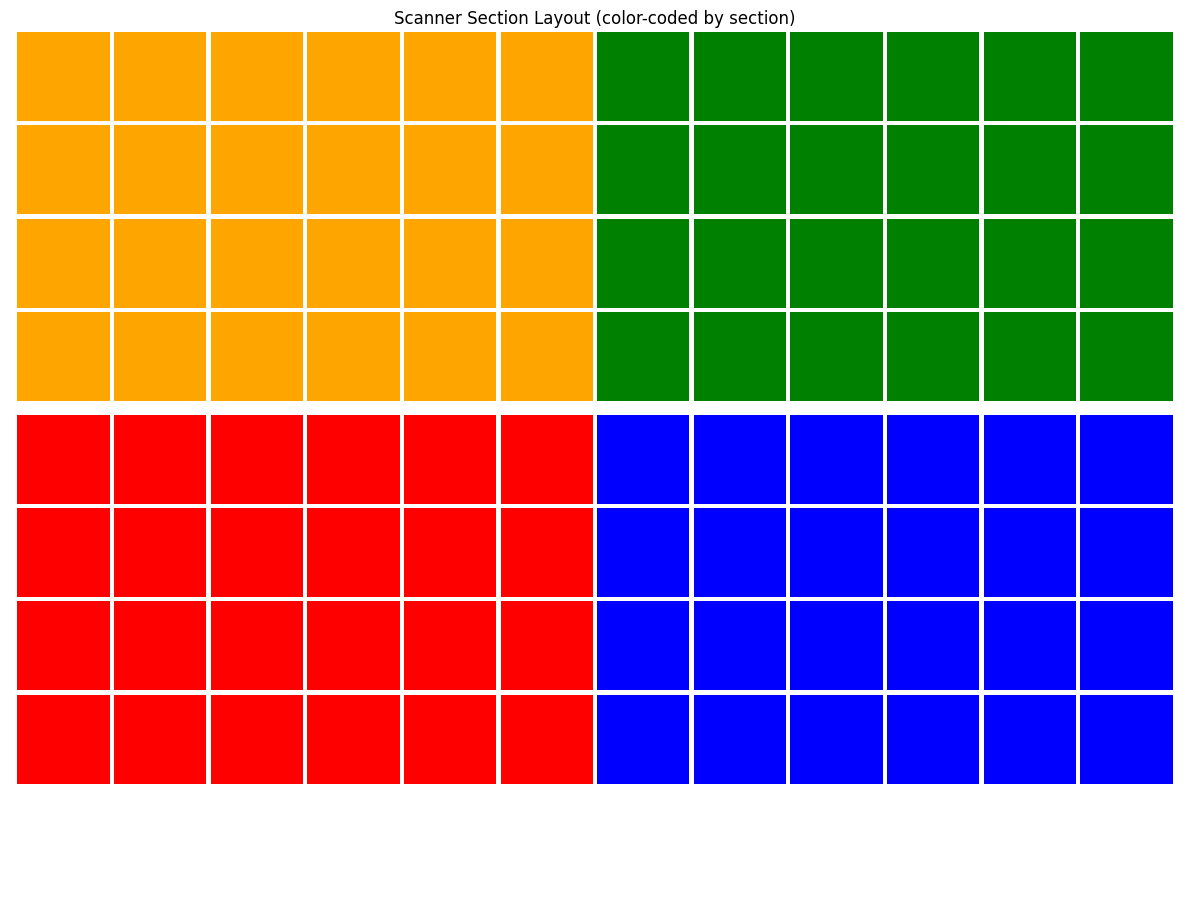

In [23]:
# Scanner layout block-style visualization, colored as per section

face_dim = 3.2
space = 1.2
blank_color = 'black'

# Section colors from ax.scatter - define lookup for each id or mask by ranges
def get_section_color(idx):
    # R Detector, then L Detector (idx = idl/idr; see map above)
    # Ranges from original code: (first 3072 are R, next 3072 are L)
    # blue: 0-1024, 1024-1280, 1792-2048
    # red: 1280-1536, 1536-1792, 2048-3072
    # green: 3072-4096, 4352-4608, 4608-4864
    # orange: 4096-4352, 4864-5120, 5120-6144
    if 0 <= idx < 1024: return 'blue'
    if 1024 <= idx < 1280: return 'blue'
    if 1280 <= idx < 1536: return 'red'
    if 1536 <= idx < 1792: return 'red'
    if 1792 <= idx < 2048: return 'blue'
    if 2048 <= idx < 3072: return 'red'
    if 3072 <= idx < 4096: return 'green'
    if 4096 <= idx < 4352: return 'orange'
    if 4352 <= idx < 4608: return 'green'
    if 4608 <= idx < 4864: return 'green'
    if 4864 <= idx < 5120: return 'orange'
    if 5120 <= idx < 6144: return 'orange'
    return 'gray'  # fallback

fig, ax = plt.subplots(figsize=(12, 9))

# Prepare 2D crystal layout from mapdf
mapL = mapdf.iloc[3072:]
mapR = mapdf.iloc[:3072]

mapL = np.round(mapL, 2)
mapR = np.round(mapR, 2)

ycoordsL, _ = np.unique(mapL.iloc[:, 1], return_counts=True)
zcoordsL, _ = np.unique(mapL.iloc[:, 2], return_counts=True)

ycoordsR, _ = np.unique(mapR.iloc[:, 1], return_counts=True)
ycoordsR = ycoordsR[::-1] # To keep view from isocenter outwards
zcoordsR, _ = np.unique(mapR.iloc[:, 2], return_counts=True)

# --- Visualize R face ---
for z in range(32):
    zspace = z // 8 * space
    for y in range(96):
        yspace = y // 8 * space
        # Map (z,y) to mapR idx
        z_actual = zcoordsR[z]
        y_actual = ycoordsR[y]
        idx_arr = np.where((np.isclose(mapR.iloc[:,2], z_actual)) & (np.isclose(mapR.iloc[:,1], y_actual)))[0]
        if len(idx_arr) > 0:
            idx = idx_arr[0]
            section_color = get_section_color(idx)
        else:
            section_color = blank_color
        rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)),
                                 face_dim, face_dim, facecolor=section_color)
        ax.add_patch(rect)

# --- Visualize L face ---
for z in range(32):
    zspace = z // 8 * space
    for y in range(96):
        yspace = y // 8 * space
        # Map (z,y) to mapL idx
        z_actual = zcoordsL[z]
        y_actual = ycoordsL[y]
        idx_arr = np.where((np.isclose(mapL.iloc[:,2], z_actual)) & (np.isclose(mapL.iloc[:,1], y_actual)))[0]
        if len(idx_arr) > 0:
            idx = idx_arr[0] + 3072  # L ids are offset by 3072
            section_color = get_section_color(idx)
        else:
            section_color = blank_color
        rect = patches.Rectangle((y*face_dim + yspace, -(z*face_dim + zspace)+110),
                                 face_dim, face_dim, facecolor=section_color)
        ax.add_patch(rect)

plt.xlim(-2,322.4)
pady = 32
plt.ylim(-104.8 - pady, 113.2)
plt.axis('off')
plt.tight_layout()
plt.title('Scanner Section Layout (color-coded by section)')
plt.show()
